In [ ]:
import numpy as np
import pandas as pd
import cv2
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import random
import seaborn as sns
import plotly.express as px
import glob
import os
import tensorflow as tf

In [ ]:
# Load The data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/Breast_Ultrasound.zip'

Archive:  /content/drive/MyDrive/Breast_Ultrasound.zip
  inflating: Dataset_BUSI_with_GT/benign/benign (1).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (1)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask_1.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (104).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (104)_mask.png  
  inflati

In [ ]:
Data_path = '/content/Dataset_BUSI_with_GT/'

In [ ]:
Malignant_path = '/content/Dataset_BUSI_with_GT/malignant/'
Malignant_image_paths = glob.glob(Malignant_path+ "*).png")
Benign_path = '/content/Dataset_BUSI_with_GT/benign/'
Benign_image_paths = glob.glob(Benign_path+ "*).png")
Healthy_path = '/content/Dataset_BUSI_with_GT/normal/'
Healthy_image_paths = glob.glob(Healthy_path+ "*).png")
Sick_Path=Malignant_path+Benign_path
Sick_image_paths=Malignant_image_paths+Benign_image_paths

In [ ]:
# visualize the data
Healthy_image_Number= len(Healthy_image_paths)
Sick_image_Number=len(Sick_image_paths)
total_img_num = Healthy_image_Number + Sick_image_Number
print('Number of Normal images: {}' .format(Healthy_image_Number))  # images of Healthy
print('Number of Sick images: {}' .format(Sick_image_Number))  # images of Sick
print('Total Number of Images : {}' .format(total_img_num))

Number of Normal images: 133
Number of Sick images: 647
Total Number of Images : 780


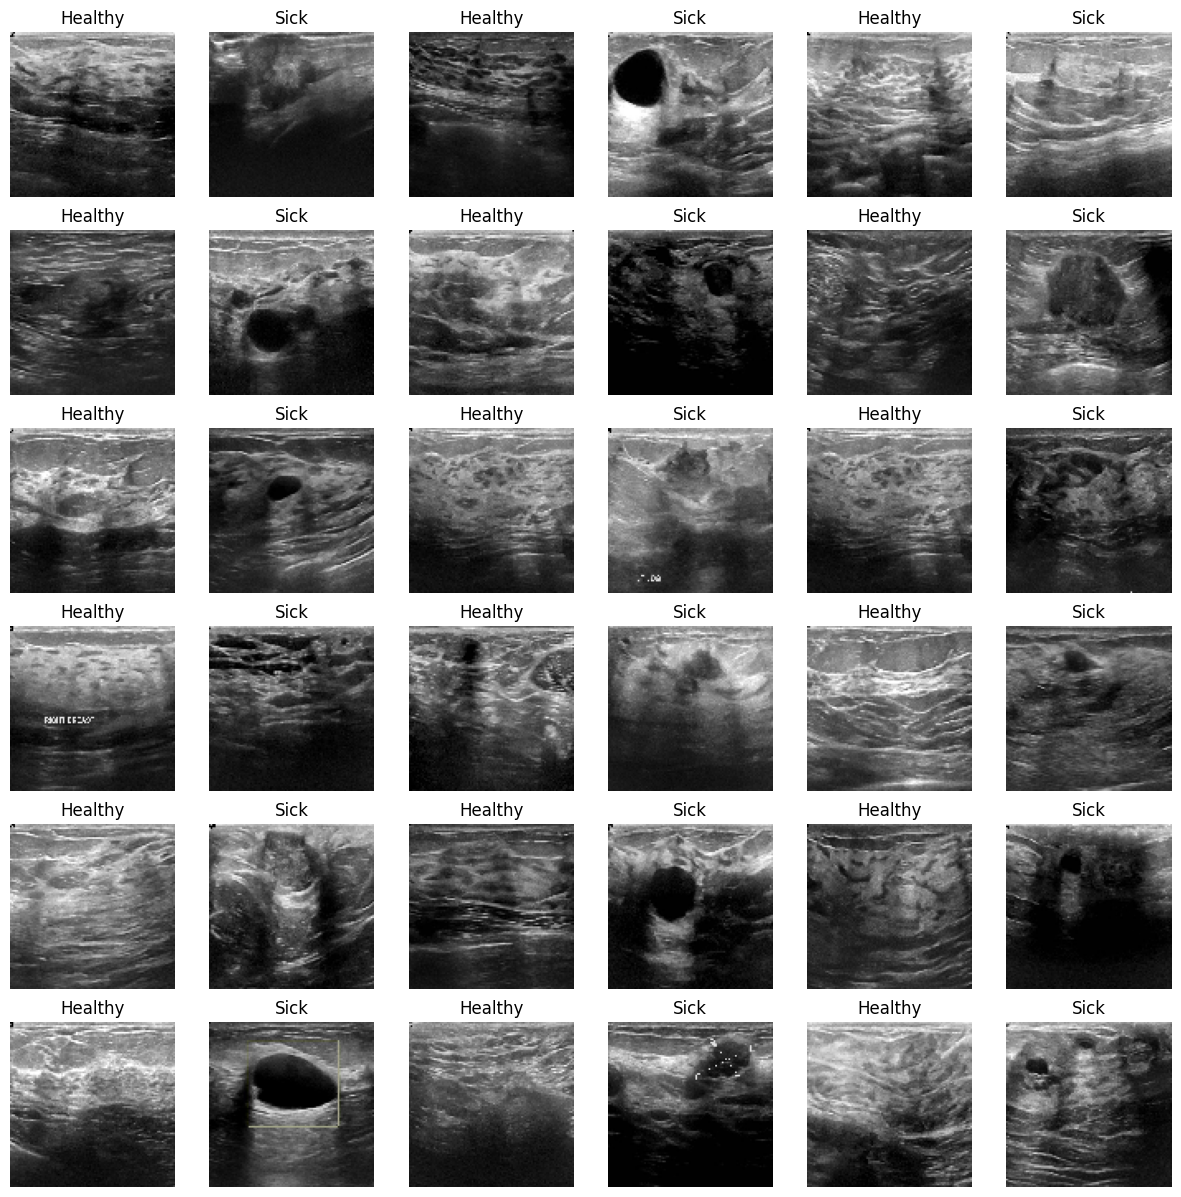

In [ ]:
from tensorflow.keras.preprocessing import image

plt.figure(figsize = (15, 15))

some_Healthy = np.random.randint(0, len(Healthy_image_paths), 18)
some_Sick = np.random.randint(0, len(Sick_image_paths), 18)

s = 0
for num in some_Healthy:

        img = image.load_img((Healthy_image_paths[num]), target_size=(100, 100))
        img = image.img_to_array(img)

        plt.subplot(6, 6, 2*s+1)
        plt.axis('off')
        plt.title('Healthy')
        plt.imshow(img.astype('uint8'))
        s += 1

s = 1
for num in some_Sick:

        img = image.load_img((Sick_image_paths[num]), target_size=(100, 100))
        img = image.img_to_array(img)
        plt.subplot(6, 6, 2*s)
        plt.axis('off')
        plt.title('Sick')
        plt.imshow(img.astype('uint8'))
        s += 1

In [ ]:
from matplotlib.image import imread
import cv2

some_Healthy_img = random.sample(Healthy_image_paths,len(Healthy_image_paths))
some_Sick_img = random.sample(Sick_image_paths, len(Sick_image_paths))

Healthy_img_arr = []
Sick_img_arr = []

for img in some_Healthy_img:

    n_img = cv2.imread(img, cv2.IMREAD_COLOR)
    n_img_color = cv2.cvtColor(n_img, cv2.COLOR_BGR2RGB)
    n_img_size = cv2.resize(n_img_color, (64,64), interpolation = cv2.INTER_LINEAR)
    for angle in range(180):
            M = cv2.getRotationMatrix2D((64/ 2, 64 / 2), angle, 3)
            img_rotated = cv2.warpAffine(n_img_size, M, (64, 64),cv2.COLOR_BGR2RGB)
            Healthy_img_arr.append([img_rotated, 0])

for img in some_Sick_img:

    c_img = cv2.imread(img, cv2.IMREAD_COLOR)
    c_img_color = cv2.cvtColor(c_img, cv2.COLOR_BGR2RGB)
    c_img_size = cv2.resize(c_img_color, (64,64), interpolation = cv2.INTER_LINEAR)
    for angle in range(180):
            M = cv2.getRotationMatrix2D((64 / 2, 64 / 2), angle, 3)
            img_rotated = cv2.warpAffine(c_img_size, M, (64, 64),cv2.COLOR_BGR2RGB)
            Sick_img_arr.append([img_rotated, 1])

In [ ]:
len(Healthy_img_arr),len(Sick_img_arr)

(23940, 116460)

In [ ]:
X = []
y = []

Data_img_arr = np.concatenate((Healthy_img_arr, Sick_img_arr))
random.shuffle(Data_img_arr)

for feature, label in Data_img_arr:
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)

print('X shape : {}' .format(X.shape))

<__array_function__ internals>:180: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


X shape : (140400, 64, 64, 3)


In [ ]:
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

print('X_train shape : {}' .format(X_train.shape))
print('X_test shape : {}' .format(X_test.shape))
print('y_train shape : {}' .format(y_train.shape))
print('y_test shape : {}' .format(y_test.shape))

X_train shape : (112320, 64, 64, 3)
X_test shape : (28080, 64, 64, 3)
y_train shape : (112320, 2)
y_test shape : (28080, 2)


In [ ]:
model = tf.keras.Sequential([
tf.keras.layers.Conv2D(32, (3, 3), padding = 'same', activation = 'relu', input_shape = (64,64,3)),
tf.keras.layers.MaxPooling2D(strides = 2),
tf.keras.layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides = 2),
tf.keras.layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides =2),
tf.keras.layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides =2),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128, activation = 'relu'),
tf.keras.layers.Dense(2, activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 15, 15, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 15, 15, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 7, 7, 128)        0

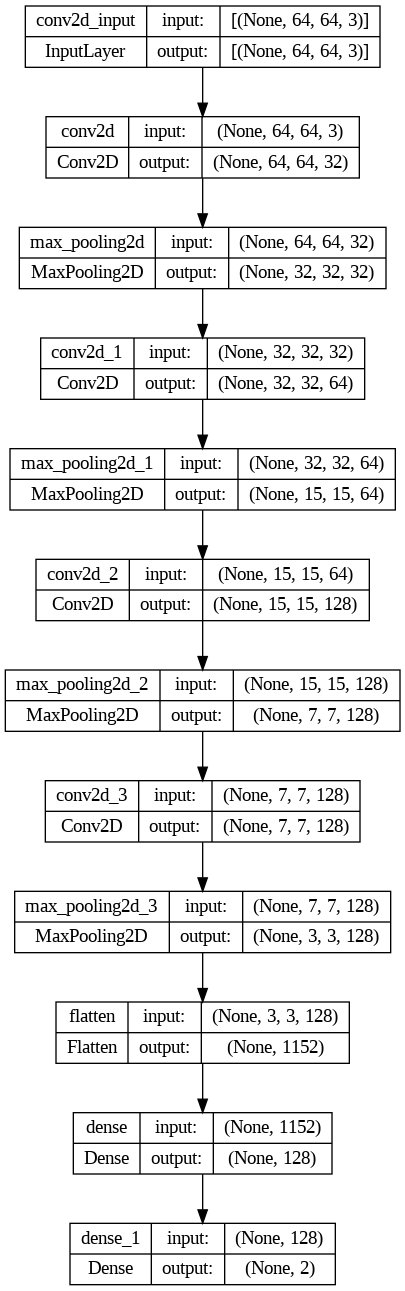

In [ ]:
tf.keras.utils.plot_model(model, "Sonography_model.png", show_shapes=True)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# trainig the model
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 40, batch_size = 85)

Epoch 1/40
1322/1322 [==============================] - 35s 16ms/step - loss: 0.4110 - accuracy: 0.8060 - val_loss: 0.1519 - val_accuracy: 0.9391
Epoch 2/40
1322/1322 [==============================] - 18s 13ms/step - loss: 0.1040 - accuracy: 0.9627 - val_loss: 0.0613 - val_accuracy: 0.9770
Epoch 3/40
1322/1322 [==============================] - 19s 14ms/step - loss: 0.0544 - accuracy: 0.9814 - val_loss: 0.0319 - val_accuracy: 0.9894
Epoch 4/40
1322/1322 [==============================] - 18s 14ms/step - loss: 0.0389 - accuracy: 0.9876 - val_loss: 0.0372 - val_accuracy: 0.9864
Epoch 5/40
1322/1322 [==============================] - 18s 14ms/step - loss: 0.0344 - accuracy: 0.9887 - val_loss: 0.0215 - val_accuracy: 0.9929
Epoch 6/40
1322/1322 [==============================] - 19s 15ms/step - loss: 0.0226 - accuracy: 0.9926 - val_loss: 0.0289 - val_accuracy: 0.9914
Epoch 7/40
1322/1322 [==============================] - 19s 15ms/step - loss: 0.0290 - accuracy: 0.9911 - val_loss: 0.0310 -

In [ ]:
#Model evaluation
Loss, Accuracy = model.evaluate(X_test,y_test)

878/878 [==============================] - 3s 3ms/step - loss: 0.0043 - accuracy: 0.9993


In [ ]:
# Report of the result of Model
print('Loss of Model is :  ',Loss)
print('Accuracy of Model is :  ',Accuracy*100,'%')

Loss of Model is :   0.004282467532902956
Accuracy of Model is :   99.92877244949341 %


878/878 [==============================] - 2s 2ms/step


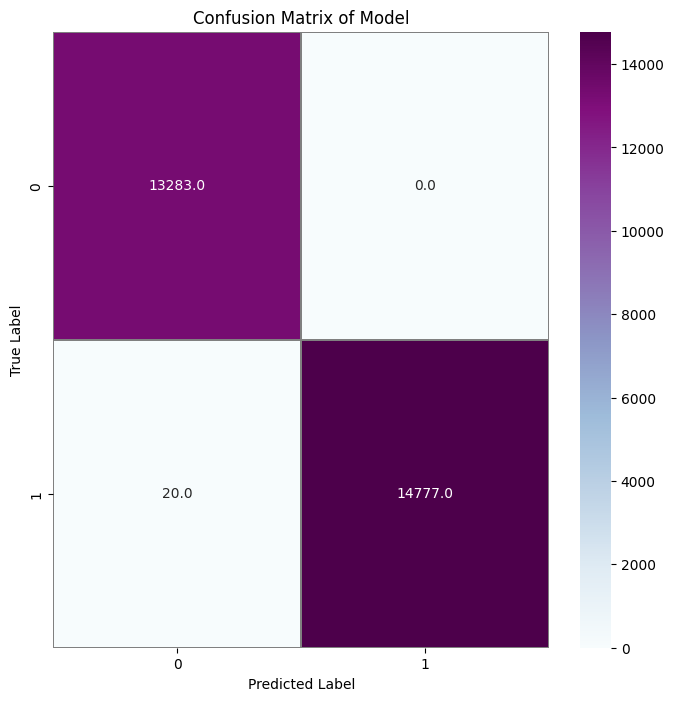

In [ ]:
from sklearn.metrics import confusion_matrix
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
Y_true = np.argmax(y_test,axis = 1)

confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="BuPu",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of Model")
plt.show()

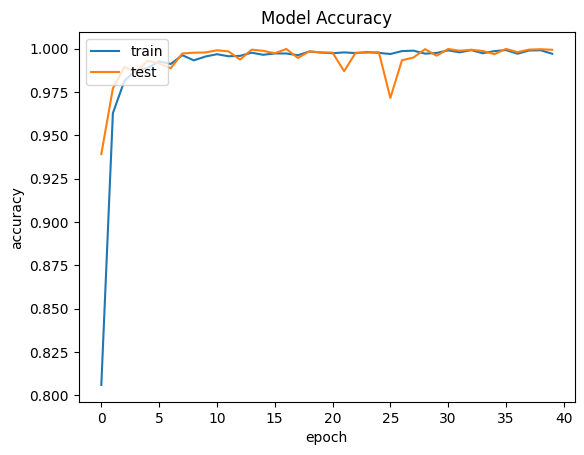

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

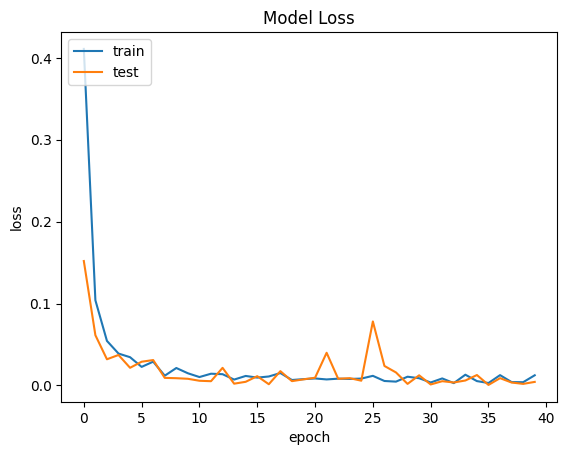

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Make prediction
prediction = model.predict(X_test)
prediction

878/878 [==============================] - 2s 2ms/step


array([[1.2699423e-23, 1.0000000e+00],
       [0.0000000e+00, 1.0000000e+00],
       [2.6665481e-05, 9.9997330e-01],
       ...,
       [1.7398682e-09, 1.0000000e+00],
       [1.0000000e+00, 5.3262670e-20],
       [1.0000000e+00, 0.0000000e+00]], dtype=float32)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, roc_auc_score, roc_curve, confusion_matrix, auc ,matthews_corrcoef
# Report of the results
prediction=np.argmax(prediction, axis=1)
y_test=np.argmax(y_test, axis=1)
print("Report of the result of Sonography_data model : \n Confusion matrix : \n {} \n\nAccuracy Score:{}% \n\nPrecision Score:{}% \n\nRecall Score: {}% \n\nf1 score Score: {}%  \n\nmcc: {}%\n\nClassification Report : \n  {}".format(
      confusion_matrix(y_test,prediction),
      round(accuracy_score(y_test,prediction),3)*100 ,
      round(precision_score(y_test,prediction),3)*100,
      round(recall_score(y_test,prediction),3)*100,
      round(f1_score(y_test,prediction),3)*100,
      round(matthews_corrcoef(y_test,prediction),3)*100,
      classification_report(y_test,prediction)))

Report of the result of Sonography_data model : 
 Confusion matrix : 
 [[13283     0]
 [   20 14777]] 

Accuracy Score:99.9% 

Precision Score:100.0% 

Recall Score: 99.9% 

f1 score Score: 99.9%  

mcc: 99.9%

Classification Report : 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00     13283
           1       1.00      1.00      1.00     14797

    accuracy                           1.00     28080
   macro avg       1.00      1.00      1.00     28080
weighted avg       1.00      1.00      1.00     28080



In [ ]:
def img_plot(arr,index=0):
    plt.title('Test Image')
    plt.imshow(arr[index].astype('uint8'))

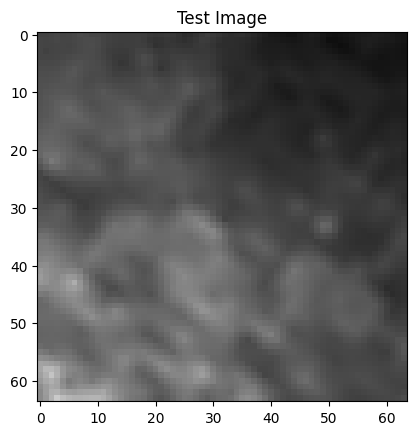

In [ ]:
index = 70
img_plot(X_test, index)

In [ ]:
input = X_test[index:index+1]

In [ ]:
pred =model.predict(input)[0].argmax()
label = y_test[index].argmax()

1/1 [==============================] - 0s 123ms/step


In [ ]:
print('Predicted Value using cnn model',pred)
print("True Value",label)

Predicted Value using cnn model 0
True Value 0
